In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import logging
import os
import sys
import numpy as np

# Add the parent directory (which contains the fmcg package) to Python path
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import fmcg
from fmcg.utils.data import load_structured_patient_data_and_noise
from fmcg.signal.filtering import filter_sensor_dict
from fmcg.signal.artifact_removal import remove_outlier_dict
from fmcg.utils.utils import sanity_check
from fmcg.utils.plotting.plot_utils import plot_sensor_signals
from fmcg.signal.whitening import apply_whitening
from fmcg.ics.functions import (
    apply_fastICA, plotICA, plotHR, upDownSample,
    identify_hr_range_segments, avg_channels_hr_range
)

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

## Data Loading and Preprocessing

In [5]:
from fmcg.configs.measurement_config_2024_07_05 import MeasurementConfig, SystemConfig, axis_mask

# settings
params = dict(
    ds_path="/fMCG_data/fMCG",
    patient="P070",
    series="S01",
    sig_group_names="R001",
    noise_group_names="R004",
    bandpass_low=1,
    bandpass_high=45,
)

# load patient data
sig_data_dict_raw, time, fs, noise_data_dict_raw = load_structured_patient_data_and_noise(
    SystemConfig,
    MeasurementConfig,
    **{k: params[k] for k in params.keys() & {"ds_path", "patient", "series", "sig_group_names", "noise_group_names"}},
    files="all",
    print_groups=True,
)

print(f"Signal Length: {len(list(sig_data_dict_raw.values())[0])/fs} s")
print(f"Noise Length: {len(list(noise_data_dict_raw.values())[0])/fs} s")

P070_S01_D2024-10-30_G27_addCh.tdms: available groups ['R001', 'R002', 'R003', 'R004']
P070_S01_D2024-10-30_G27.tdms: available groups ['R001', 'R002', 'R003', 'R004']
P070_S01_D2024-10-30_G27.tdms: available groups ['R001', 'R002', 'R003', 'R004']
Signal Length: 297.468 s
Noise Length: 57.211 s
Signal Length: 297.468 s
Noise Length: 57.211 s


/home/jonas/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
      F1     | OX     | OU     | OQ     | YQ     | EZ     | OY     | OW ⚠️  | OT     | NL     | F0     | C1     | EY     | YP     | OR ⚠️  | F2    
---------------------------------------------------------------------------------------------------------------------------------------------------
X        nan |   6.17 |    nan |   6.27 |   7.11 |    nan |   5.24 |    nan |    nan |   4.50 |    nan |   4.95 |   5.15 |    nan |   0.05 |    nan
Y       6.57 |   7.02 |   6.50 |   7.09 |   6.13 |   6.28 |   6.18 |   0.07 |   5.91 |   5.16 |   5.03 |   5.37 |   6.24 |   5.48 |   0.07 |   4.79
Z       9.24 |    nan |   9.15 |    nan |    nan |   9.14 |    nan |   0.05 |  11.10 |   7.63 |   8.26 |    nan |    nan |   9.32 |    nan |   7.83
WARNING (Physical Range Threshold): Sensor 'OW' channel Y have physical range 0.074 (threshold 1). Mark

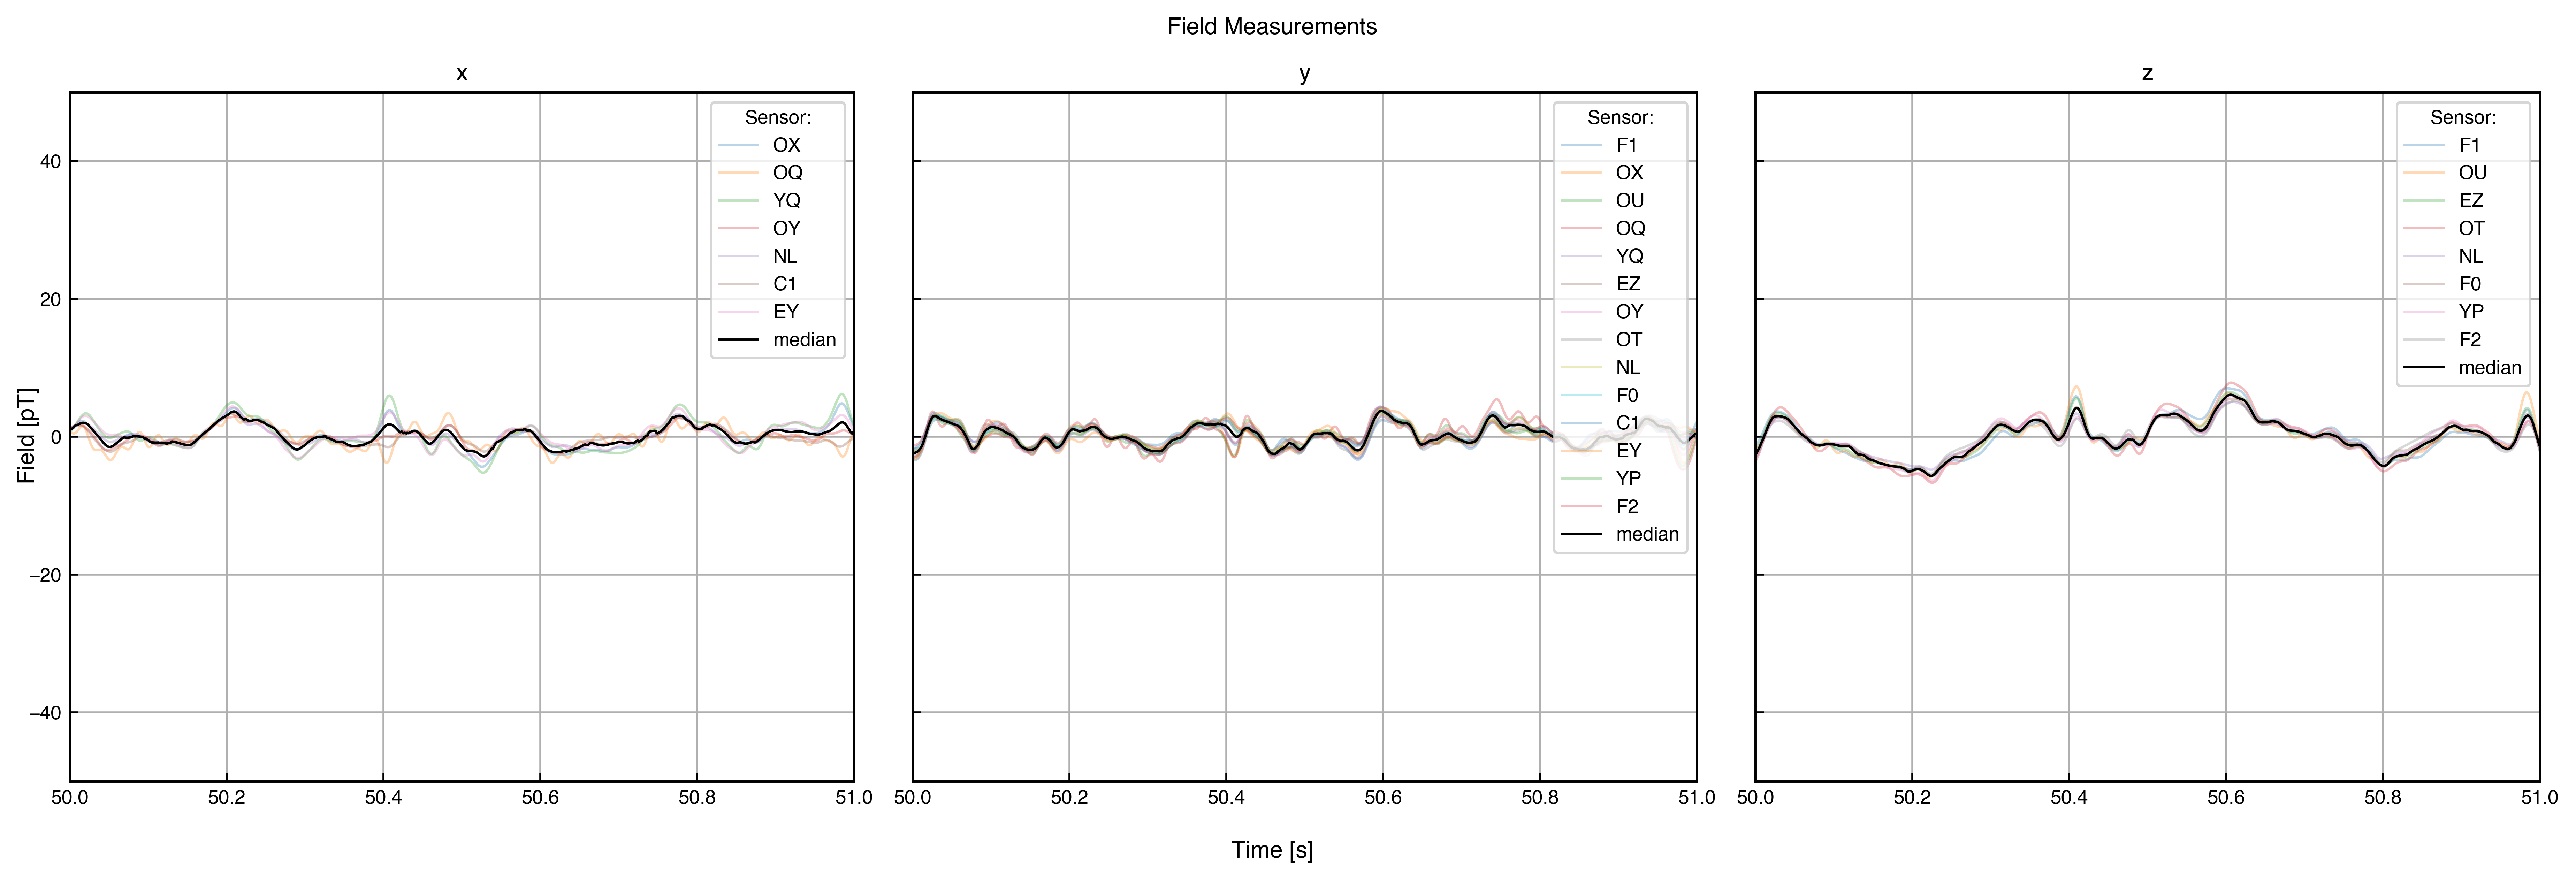

In [6]:
# performing basic preprocessing (filtering and removal of outlying sensor channels)

# frequency filtering (bandpass + notch)
sensor_dict = filter_sensor_dict(sig_data_dict_raw, fs, low=params['bandpass_low'], high=params["bandpass_high"], order=4)
noise_sensor_dict = filter_sensor_dict(noise_data_dict_raw, fs, low=params['bandpass_low'], high=params["bandpass_high"], order=4)

# remove outlying channels with unphysical range (by variability threshold + comparison across array)
sensor_dict, axis_mask = remove_outlier_dict(sensor_dict, physical_range_threshold=1, verbose=True)
noise_sensor_dict, axis_mask_noise = remove_outlier_dict(noise_sensor_dict, physical_range_threshold=.1, verbose=True)

# axis mask provides valid channels
axis_mask = axis_mask & axis_mask_noise

# plot channels overlayed to check if they are aligned -> potential error in orientation of sensor coordinates (see SystemConfig)
sanity_check(sensor_dict, time, ylim=[-50, 50], xlim=[50, 51])

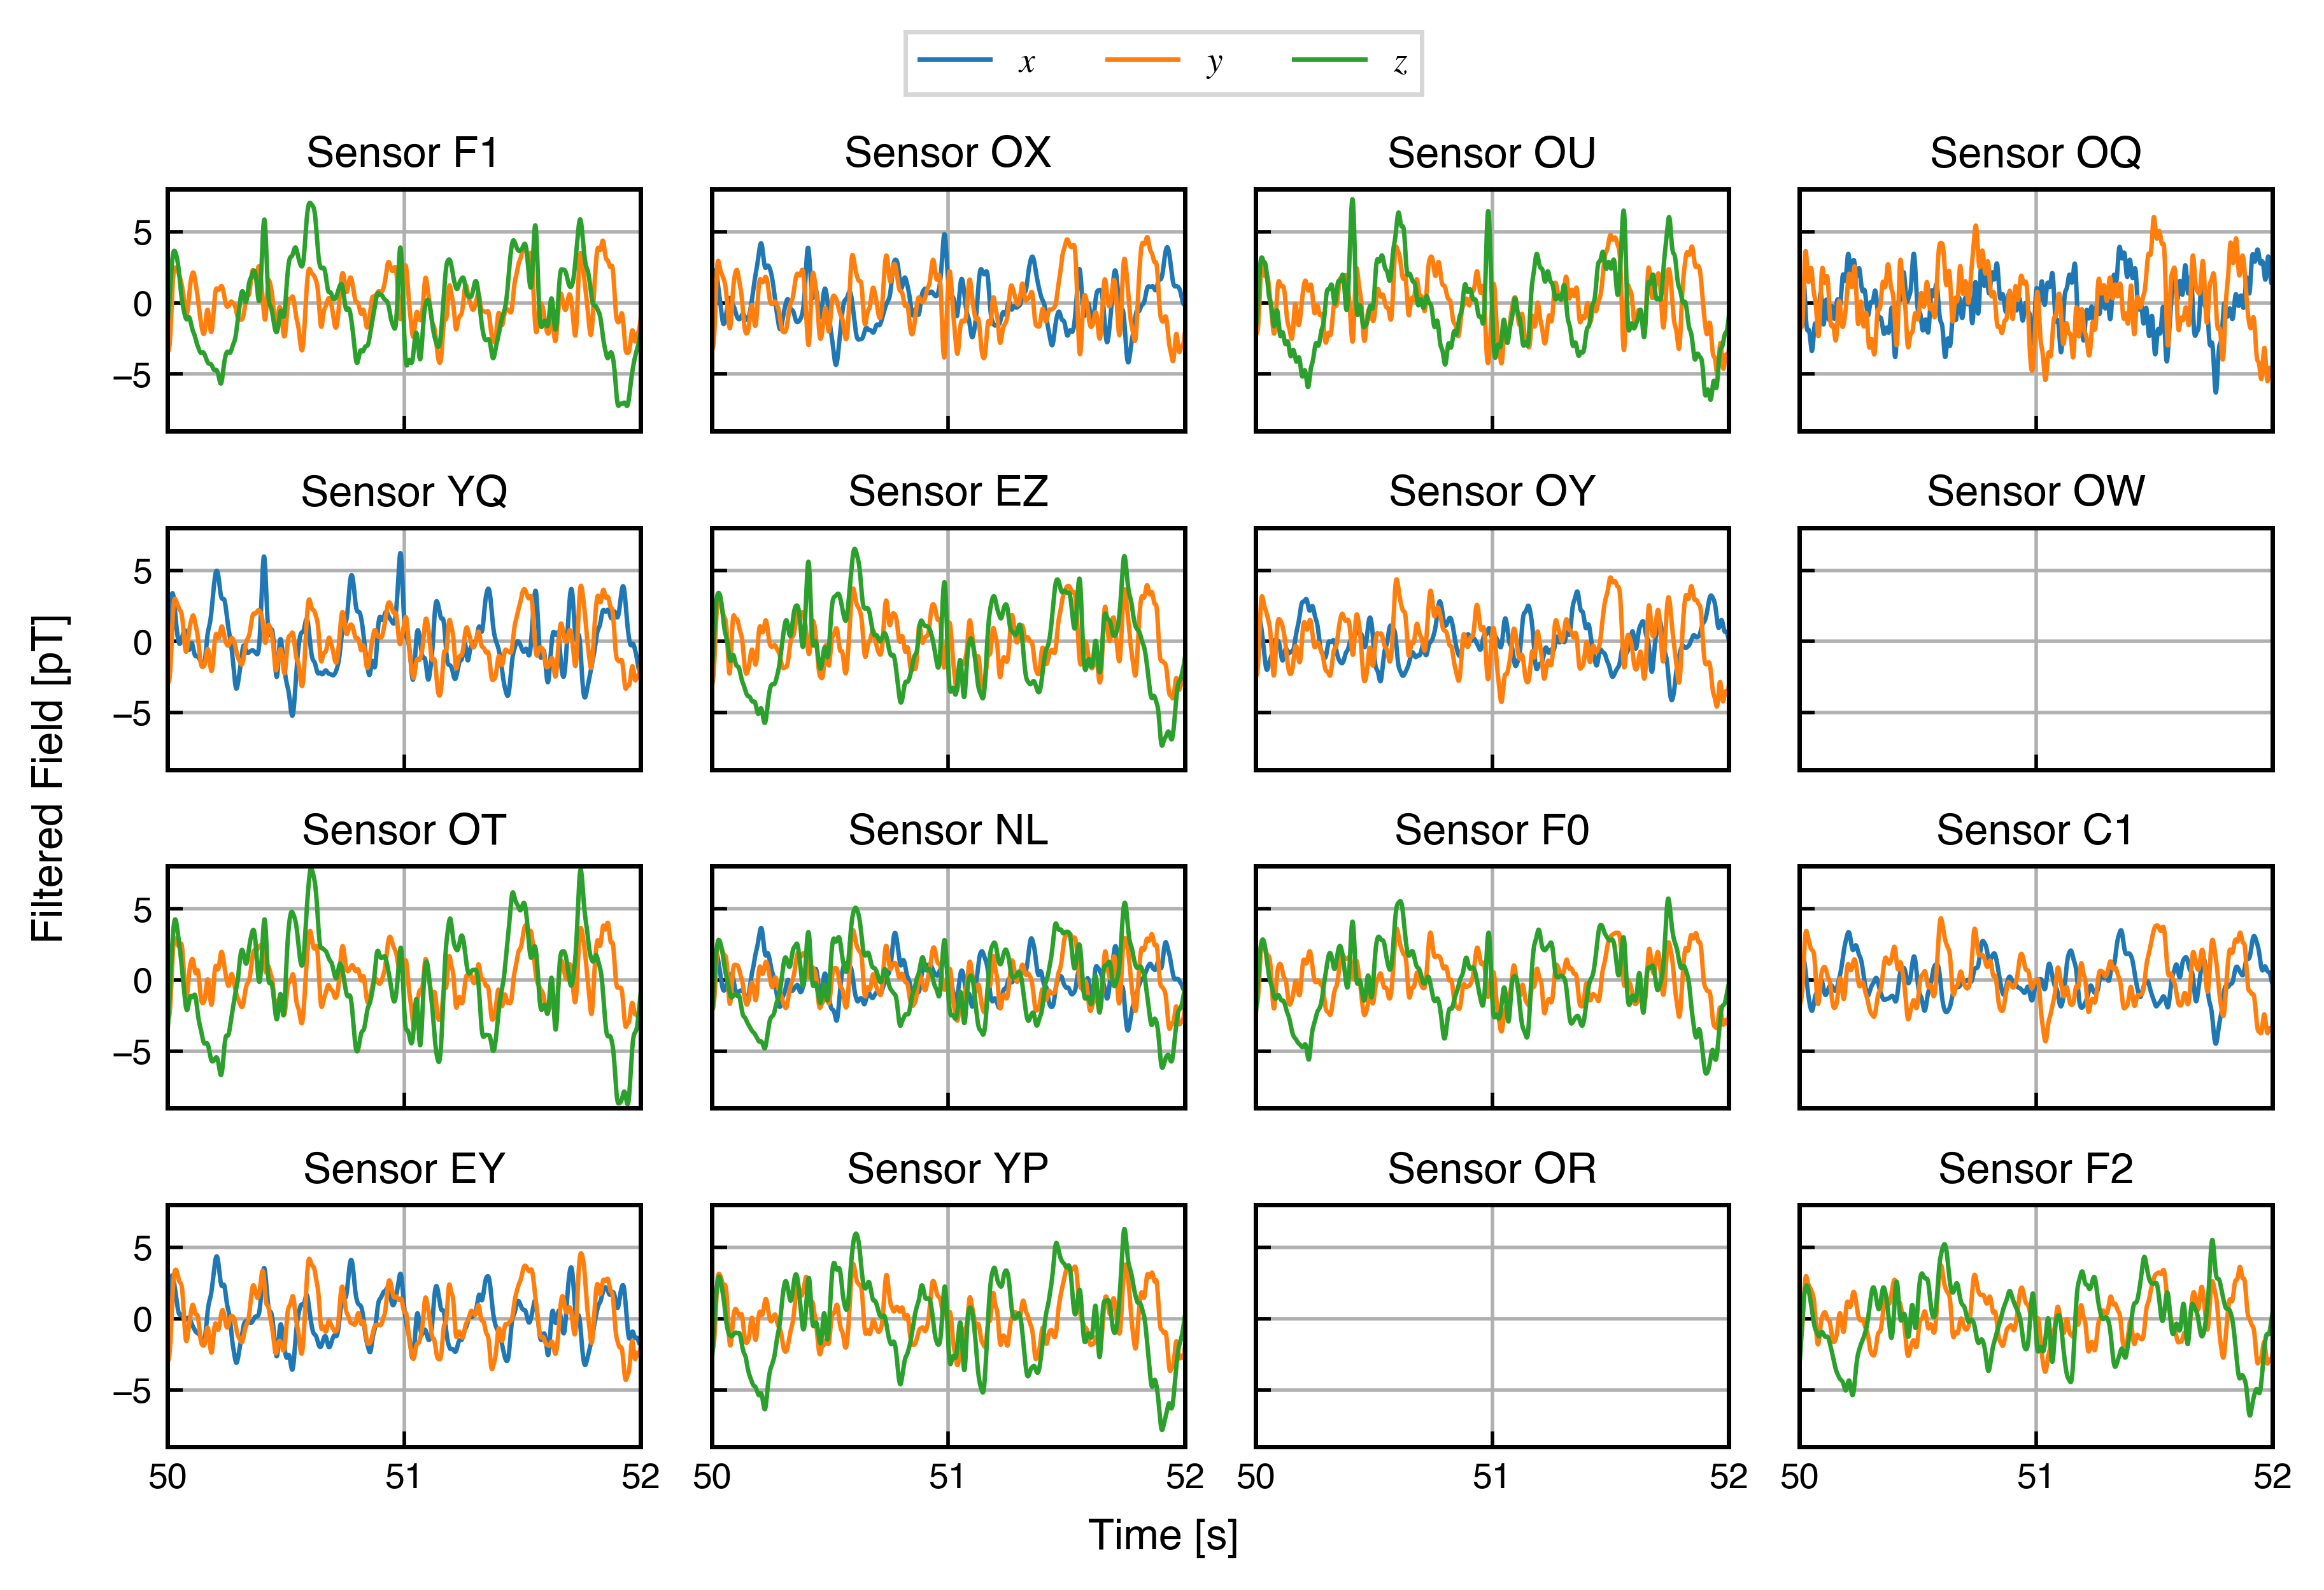

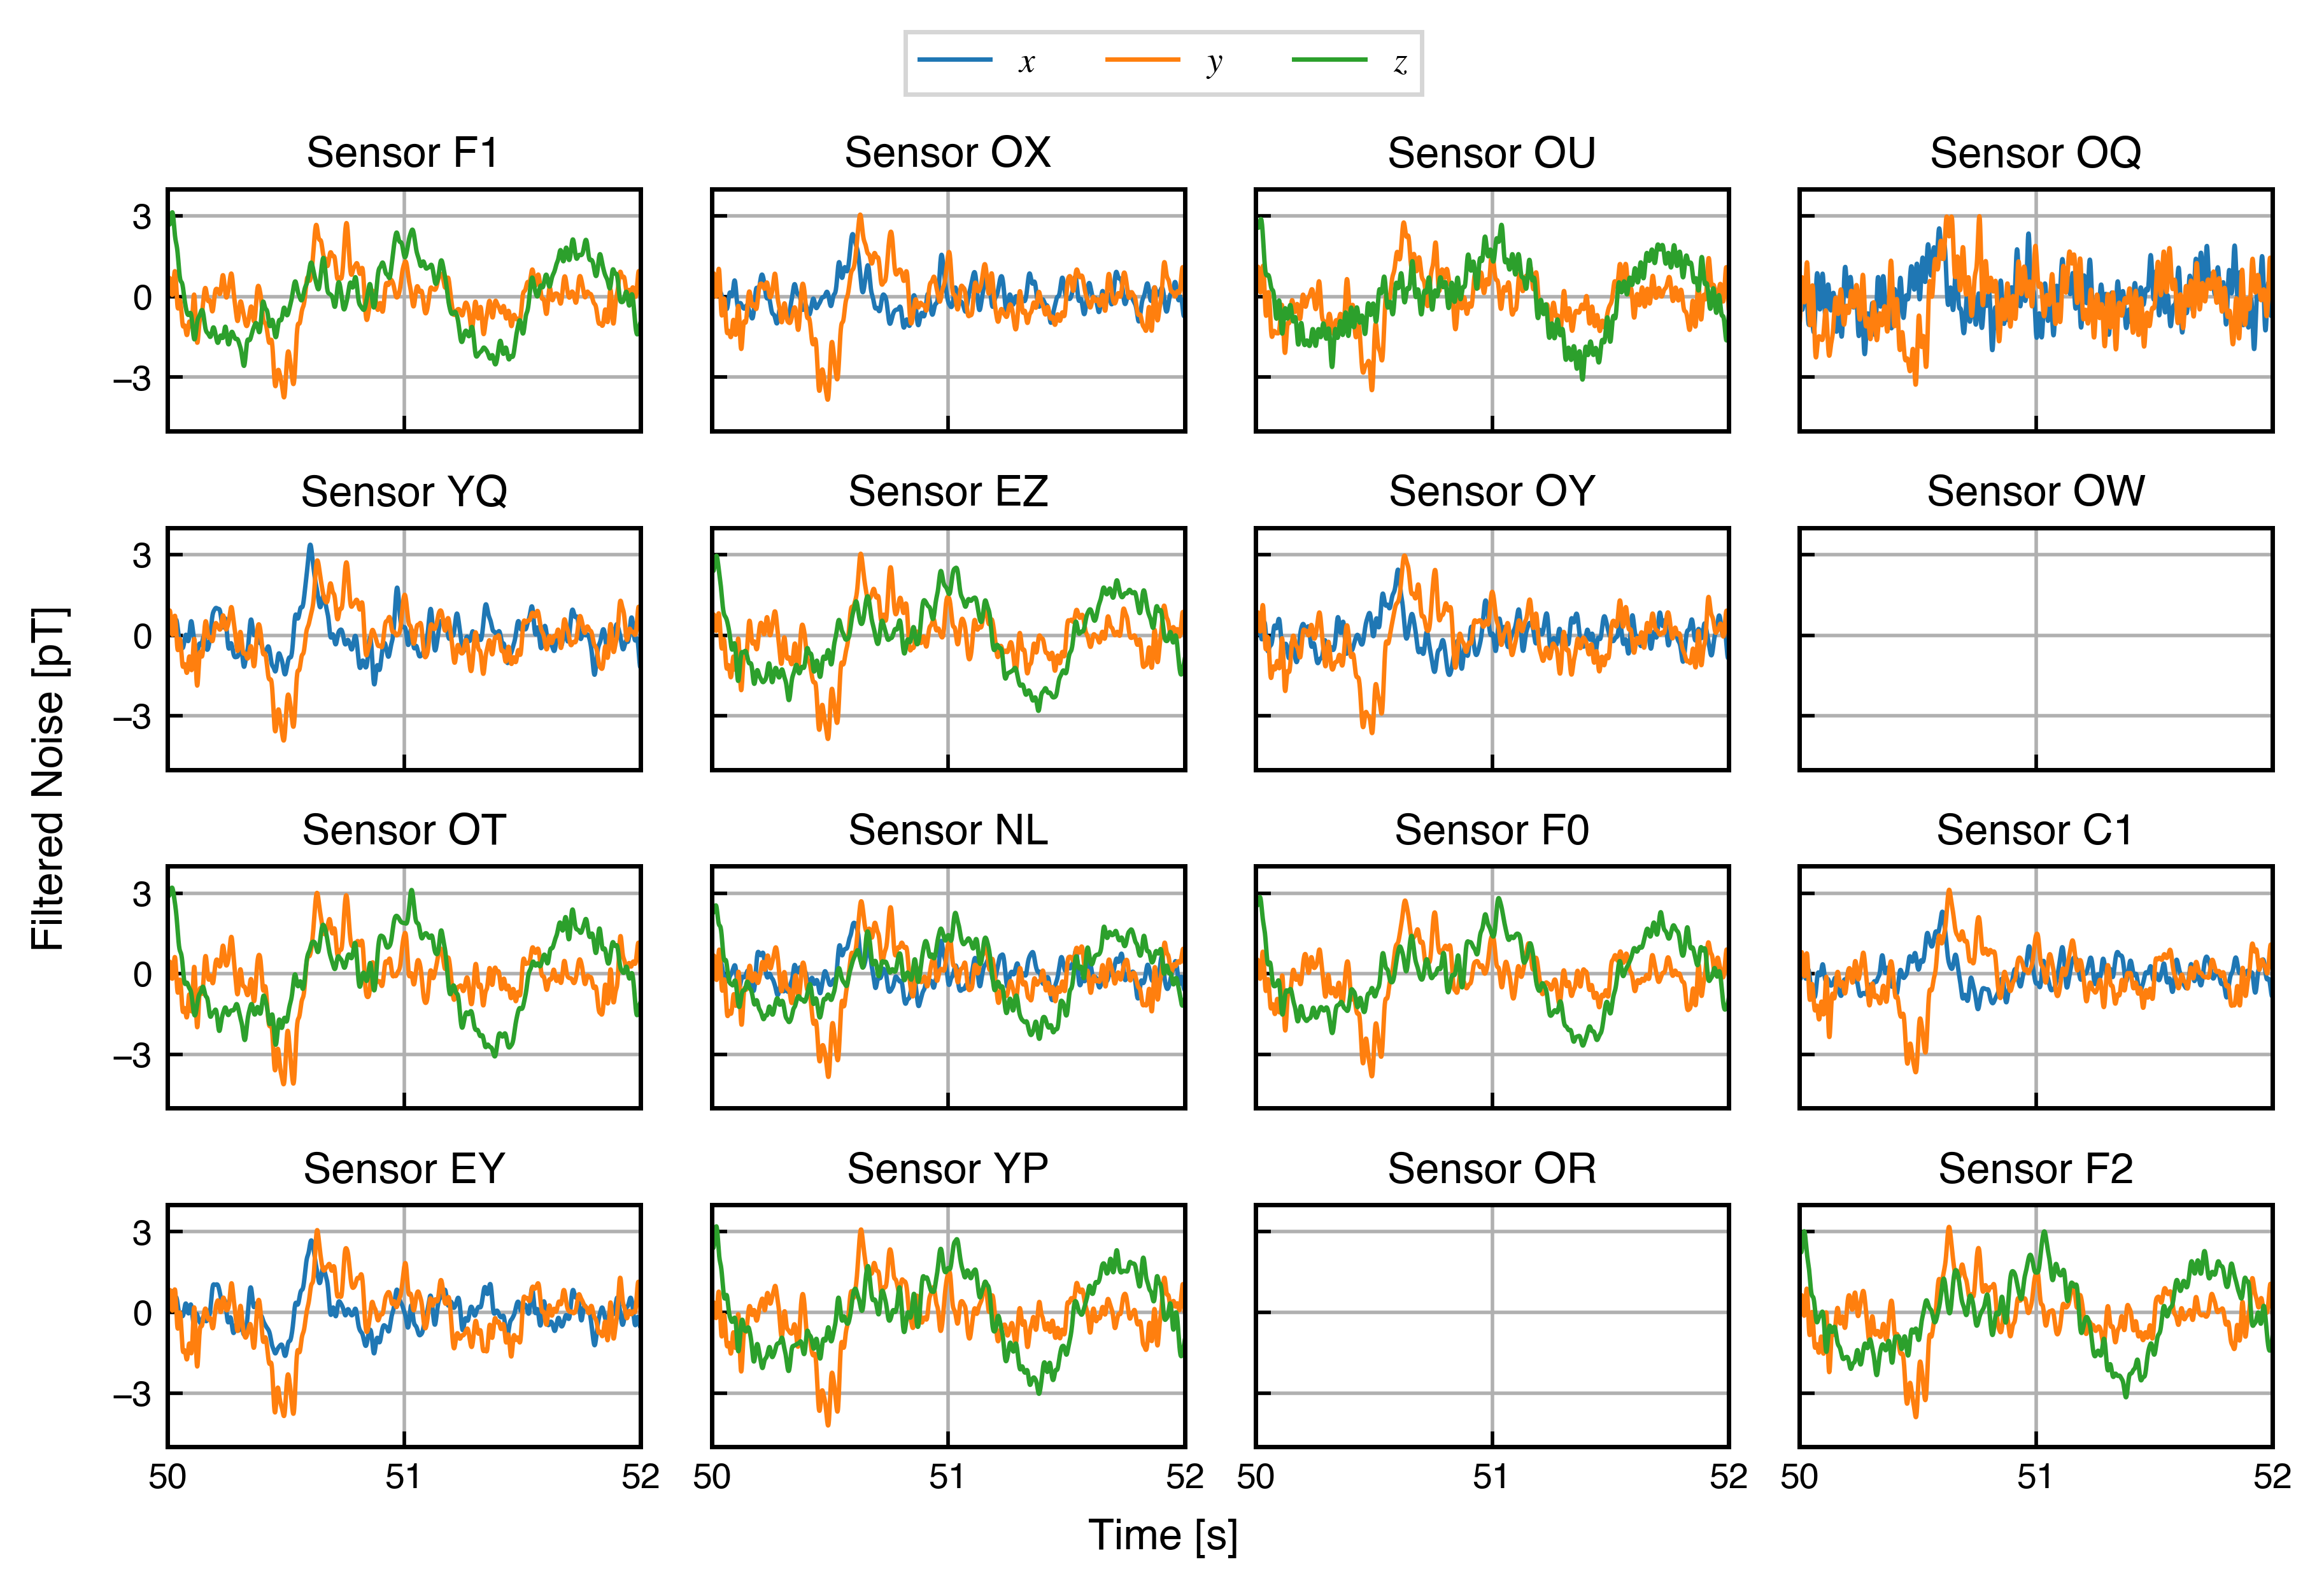

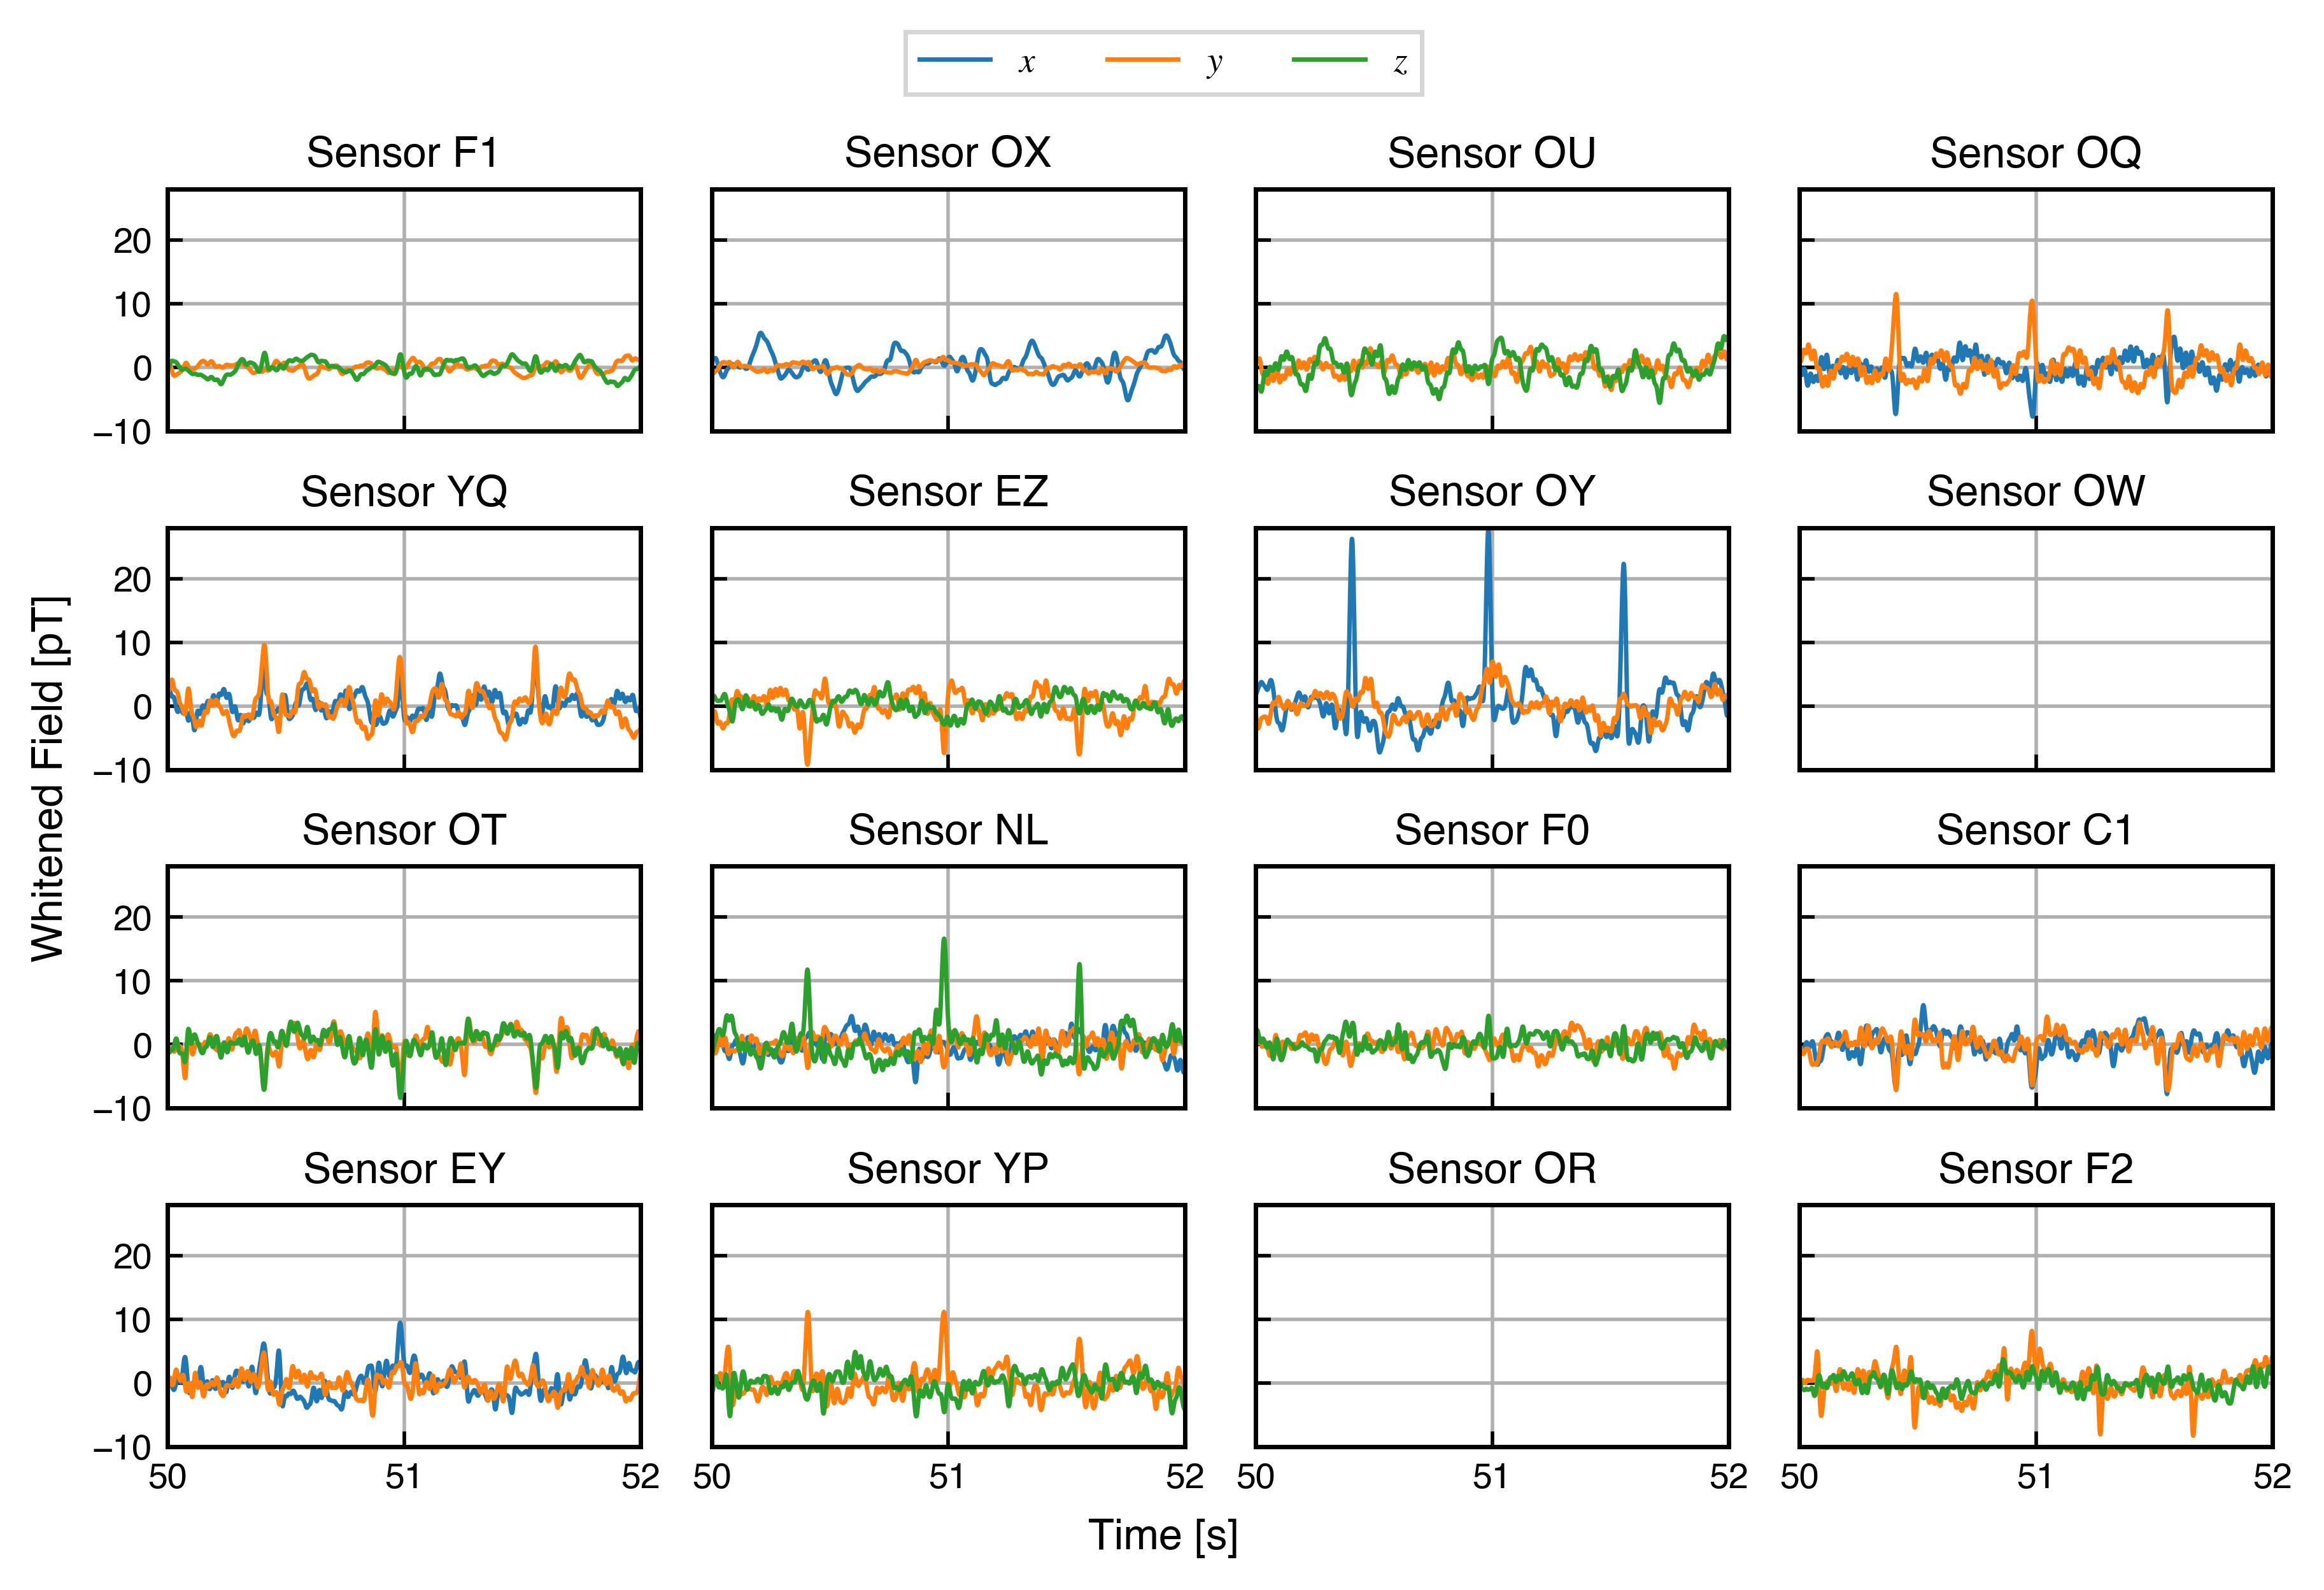

In [7]:
field_maps = np.array([v for k, v in sensor_dict.items()]).transpose(1, 0, 2)
noise_maps = np.array([v for k, v in noise_sensor_dict.items()]).transpose(1, 0, 2)

plot_sensor_signals(
    field_maps,
    time,
    ylabel="Filtered Field [pT]",
    xlim=[50, 52],
    sharey=True,
    sensor_names=list(sensor_dict.keys()),
)

plot_sensor_signals(
    noise_maps,
    np.arange(noise_maps.shape[0]) / fs,
    ylabel="Filtered Noise [pT]",
    xlim=[50, 52],
    sharey=True,
    sensor_names=list(sensor_dict.keys()),
)


# Apply whitening to the recording using noise structure
field_maps, W = apply_whitening(
    field_maps,
    noise_maps,
    axis_mask,
    method="PCA",
    return_whitening_matrix=True,
    rescale=True,
)

plot_sensor_signals(
    field_maps,
    time,
    ylabel="Whitened Field [pT]",
    xlim=[50, 52],
    sharey=True,
    sensor_names=list(sensor_dict.keys()),
)

## Independent Component Subtraction (ICS)

/opt/conda/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


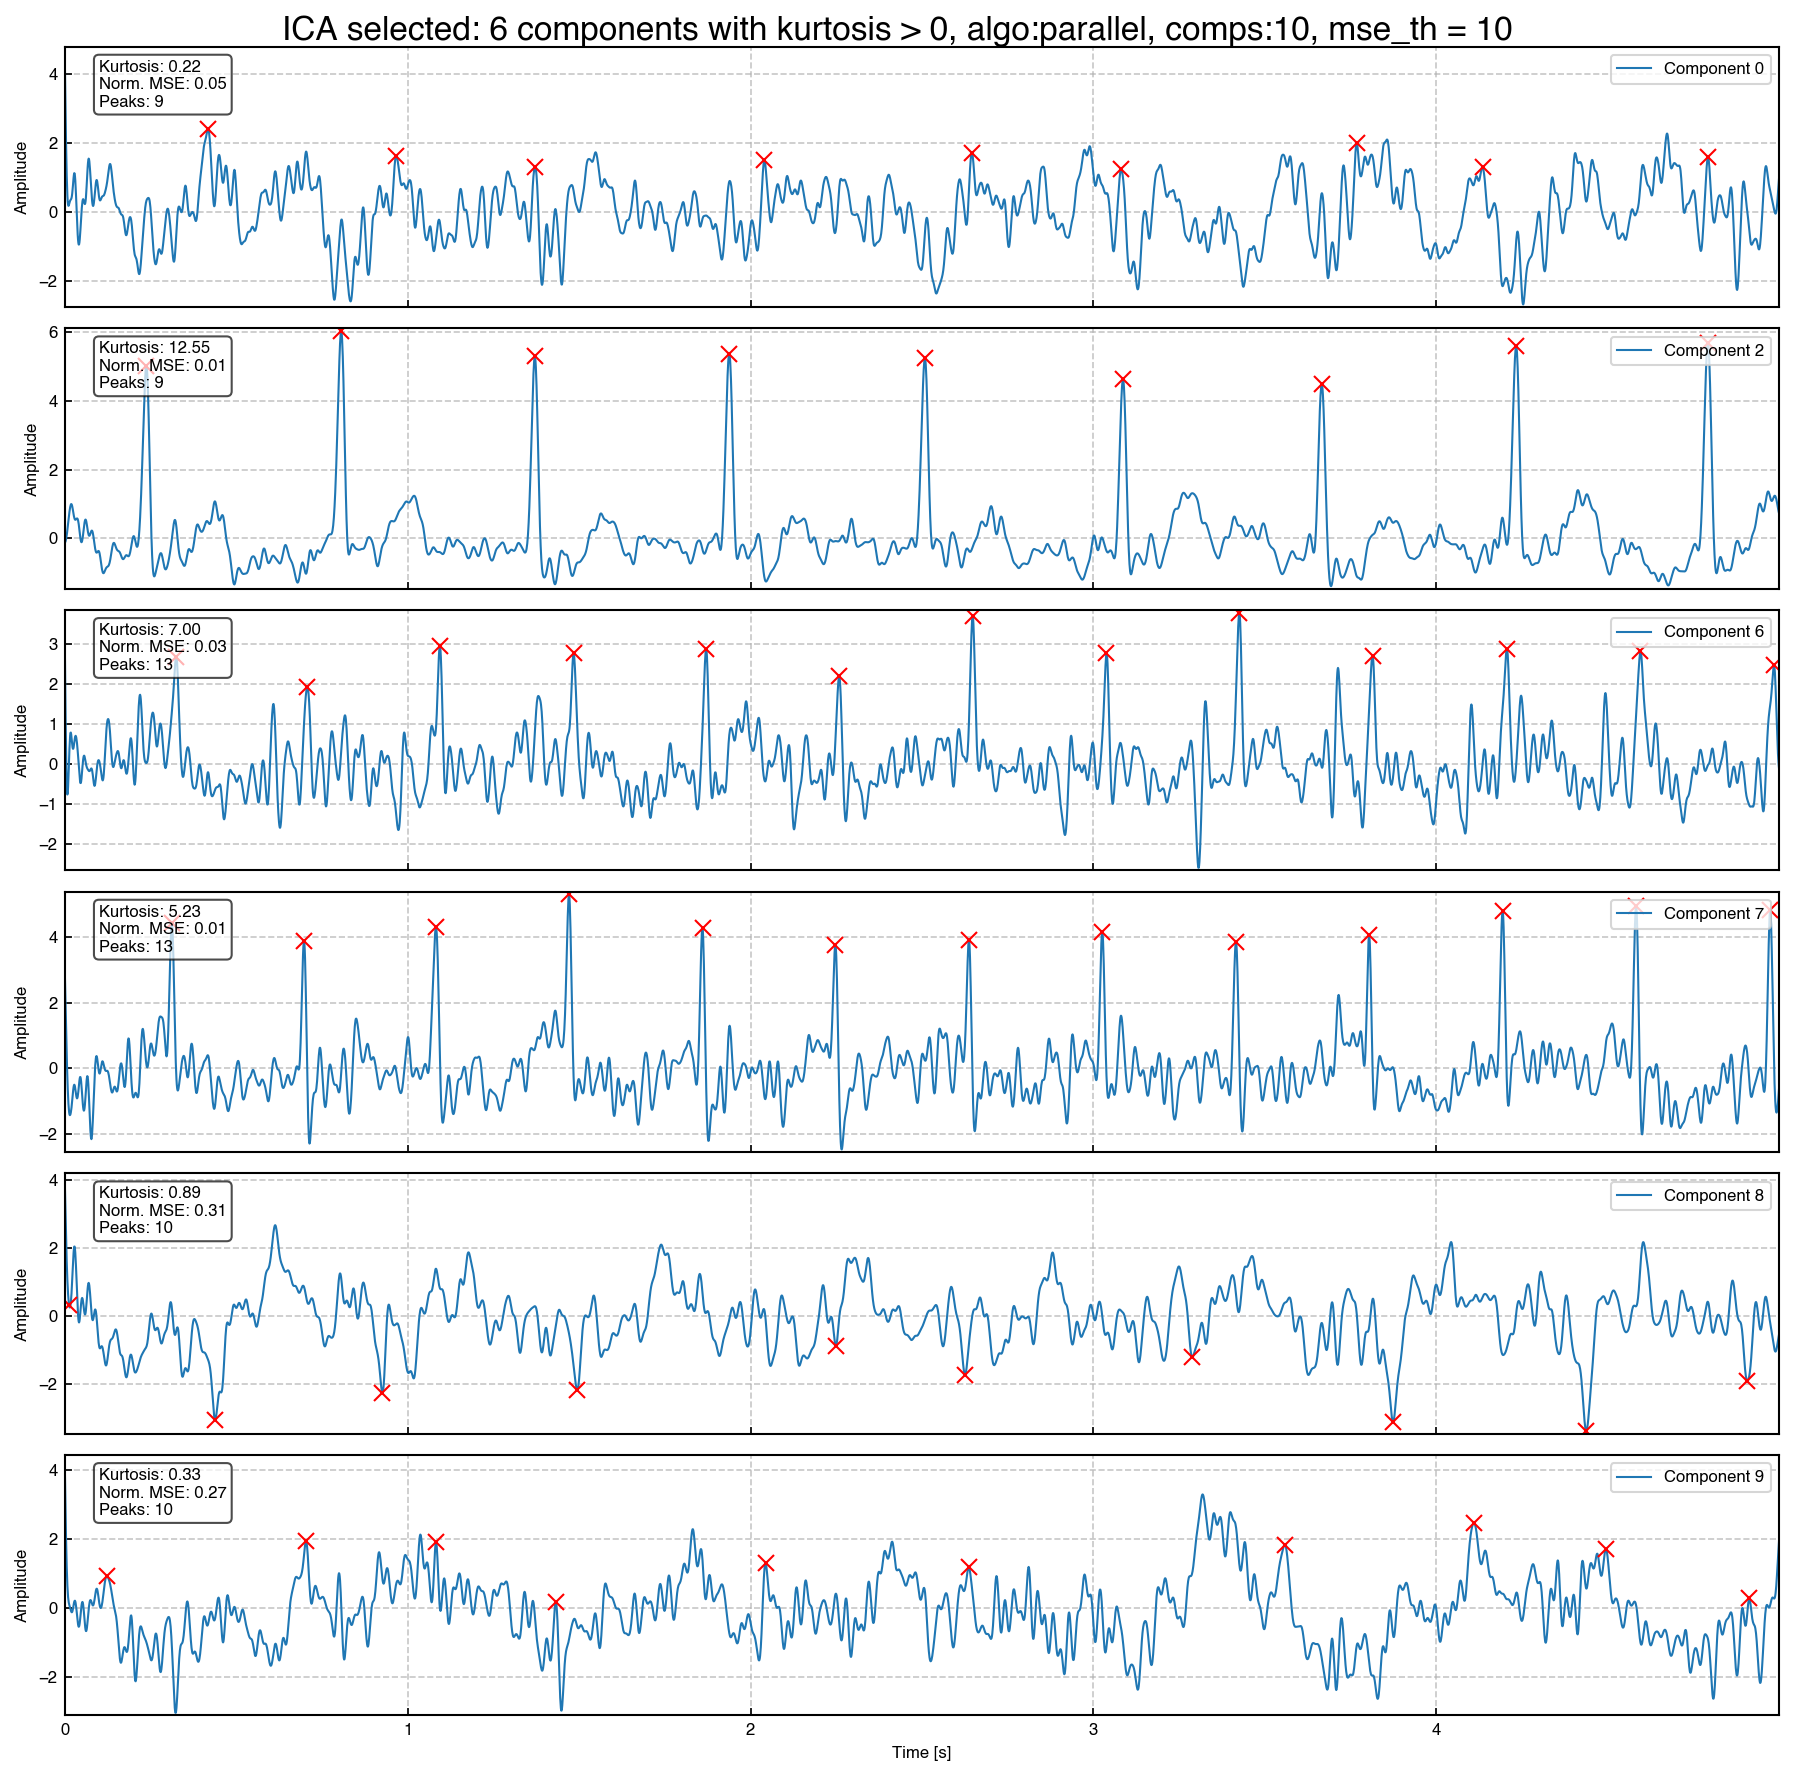

In [10]:
from copy import deepcopy
bp_data = field_maps[:, axis_mask]

# normally, they were using deflation algorithm but parallel is much much faster, and produce similar results
sources, ica = apply_fastICA(bp_data, n_comp=10, algo='parallel')
compF, maternals = plotICA(sources, ica, offset=0*fs, span=5*fs, kurt_threshold=0, mse_th=10, plt_save=False, fs=fs)
ica_mixing_ = ica.mixing_.copy()

In [11]:
# manual component selection of fetal and maternal components
compF = [6,7]
maternals = [2]

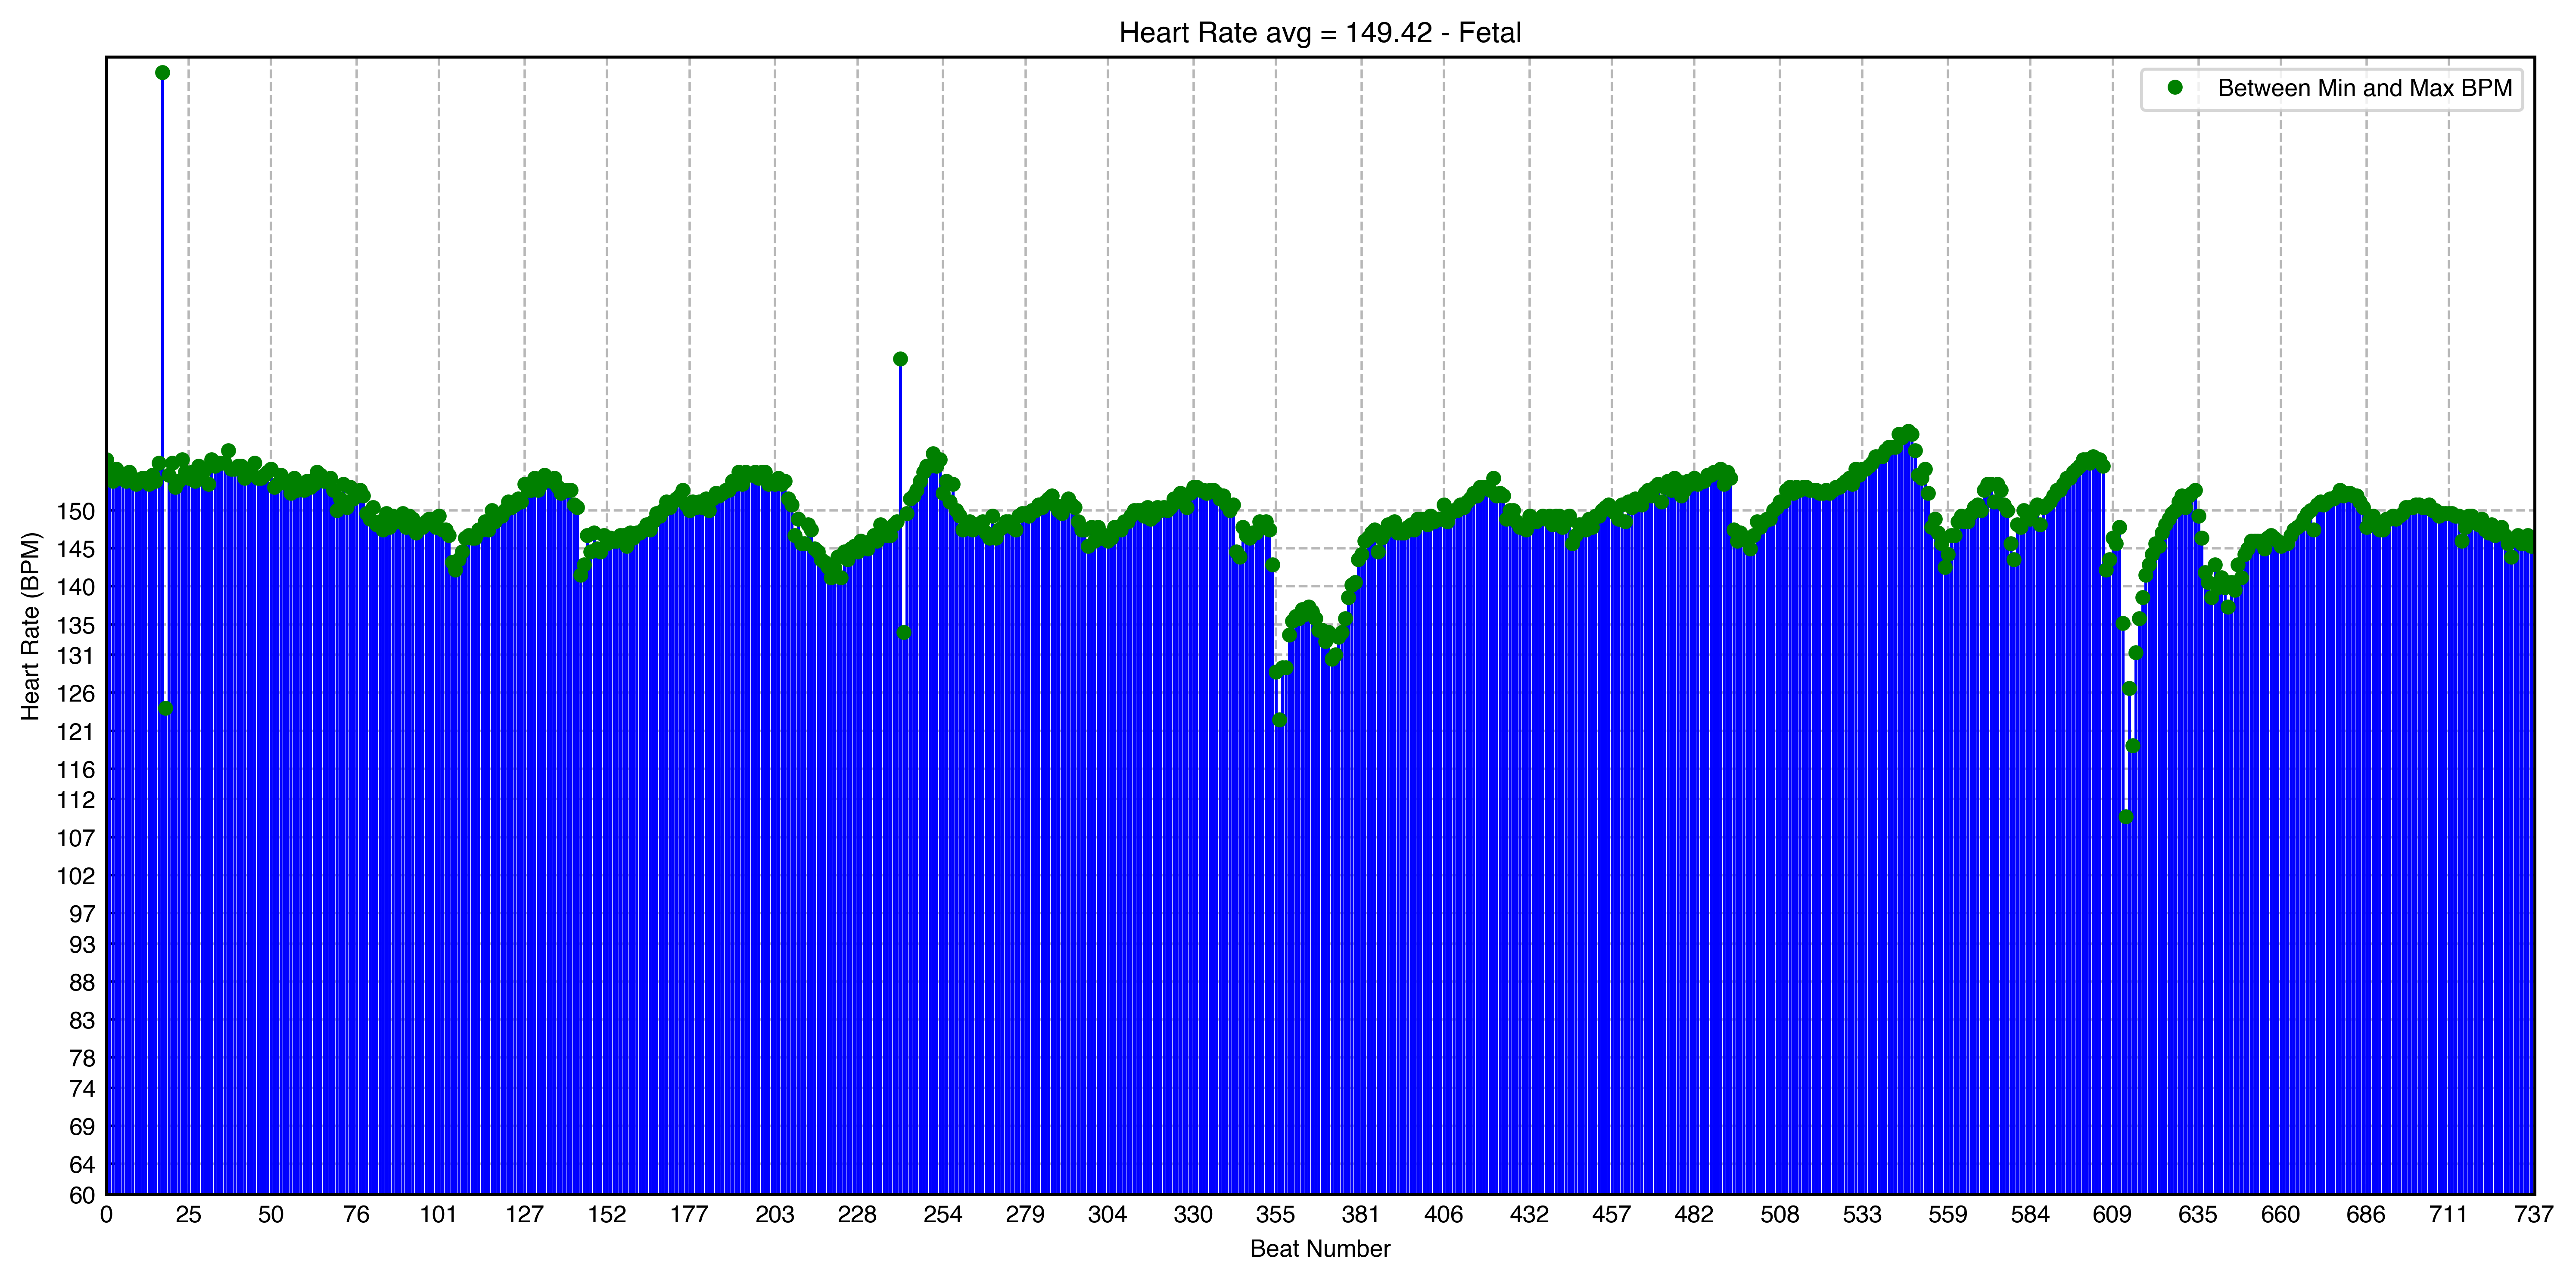

In [12]:
# Compute Heartrate of fetal cardiac signal
heartRate, peaks = plotHR(sources[:, compF[0]], fs=fs)

In [13]:
# Isolate the maternal sources by removing the fetal components in the ICA domain

ica.mixing_ = ica_mixing_.copy()
ica.mixing_[:, compF] = 0
maternal_sources = deepcopy(sources)
maternal_sources[:, compF] = 0

In [14]:
# Smooth the maternal signals and subtract them in the signal / field domain of our measured field
# (Splined Maternal Component Subtraction)

maternal_corrected = upDownSample(
    maternal_sources, maternals, downsample_factor_qrs=5, downsample_factor_other=20
)
maternal_meas = ica.inverse_transform(maternal_corrected, True)
remaining_fetal = bp_data - maternal_meas

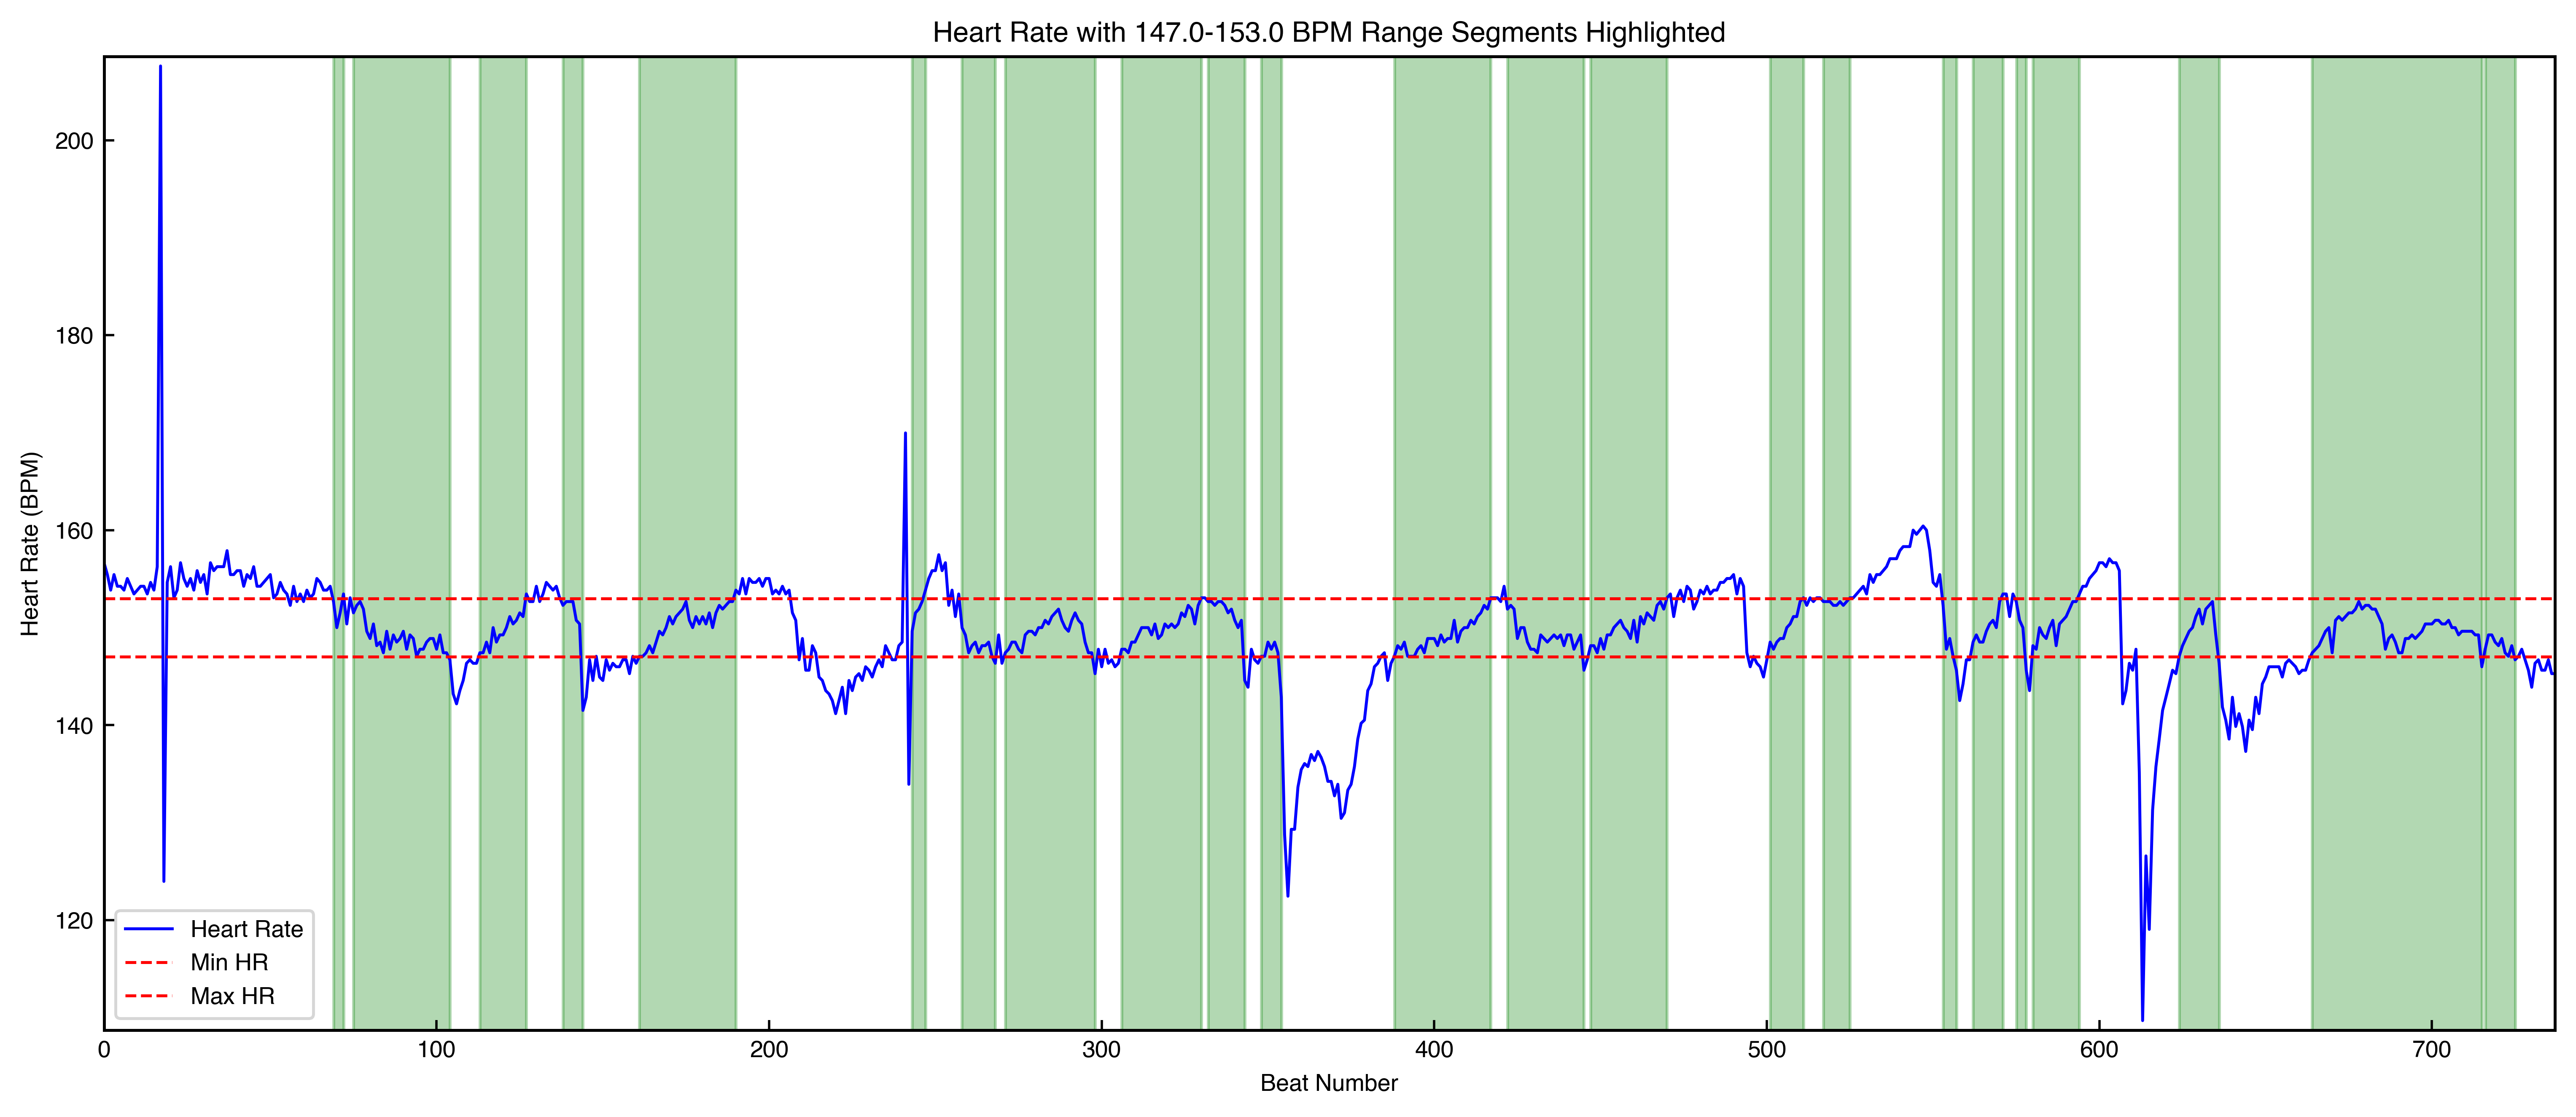

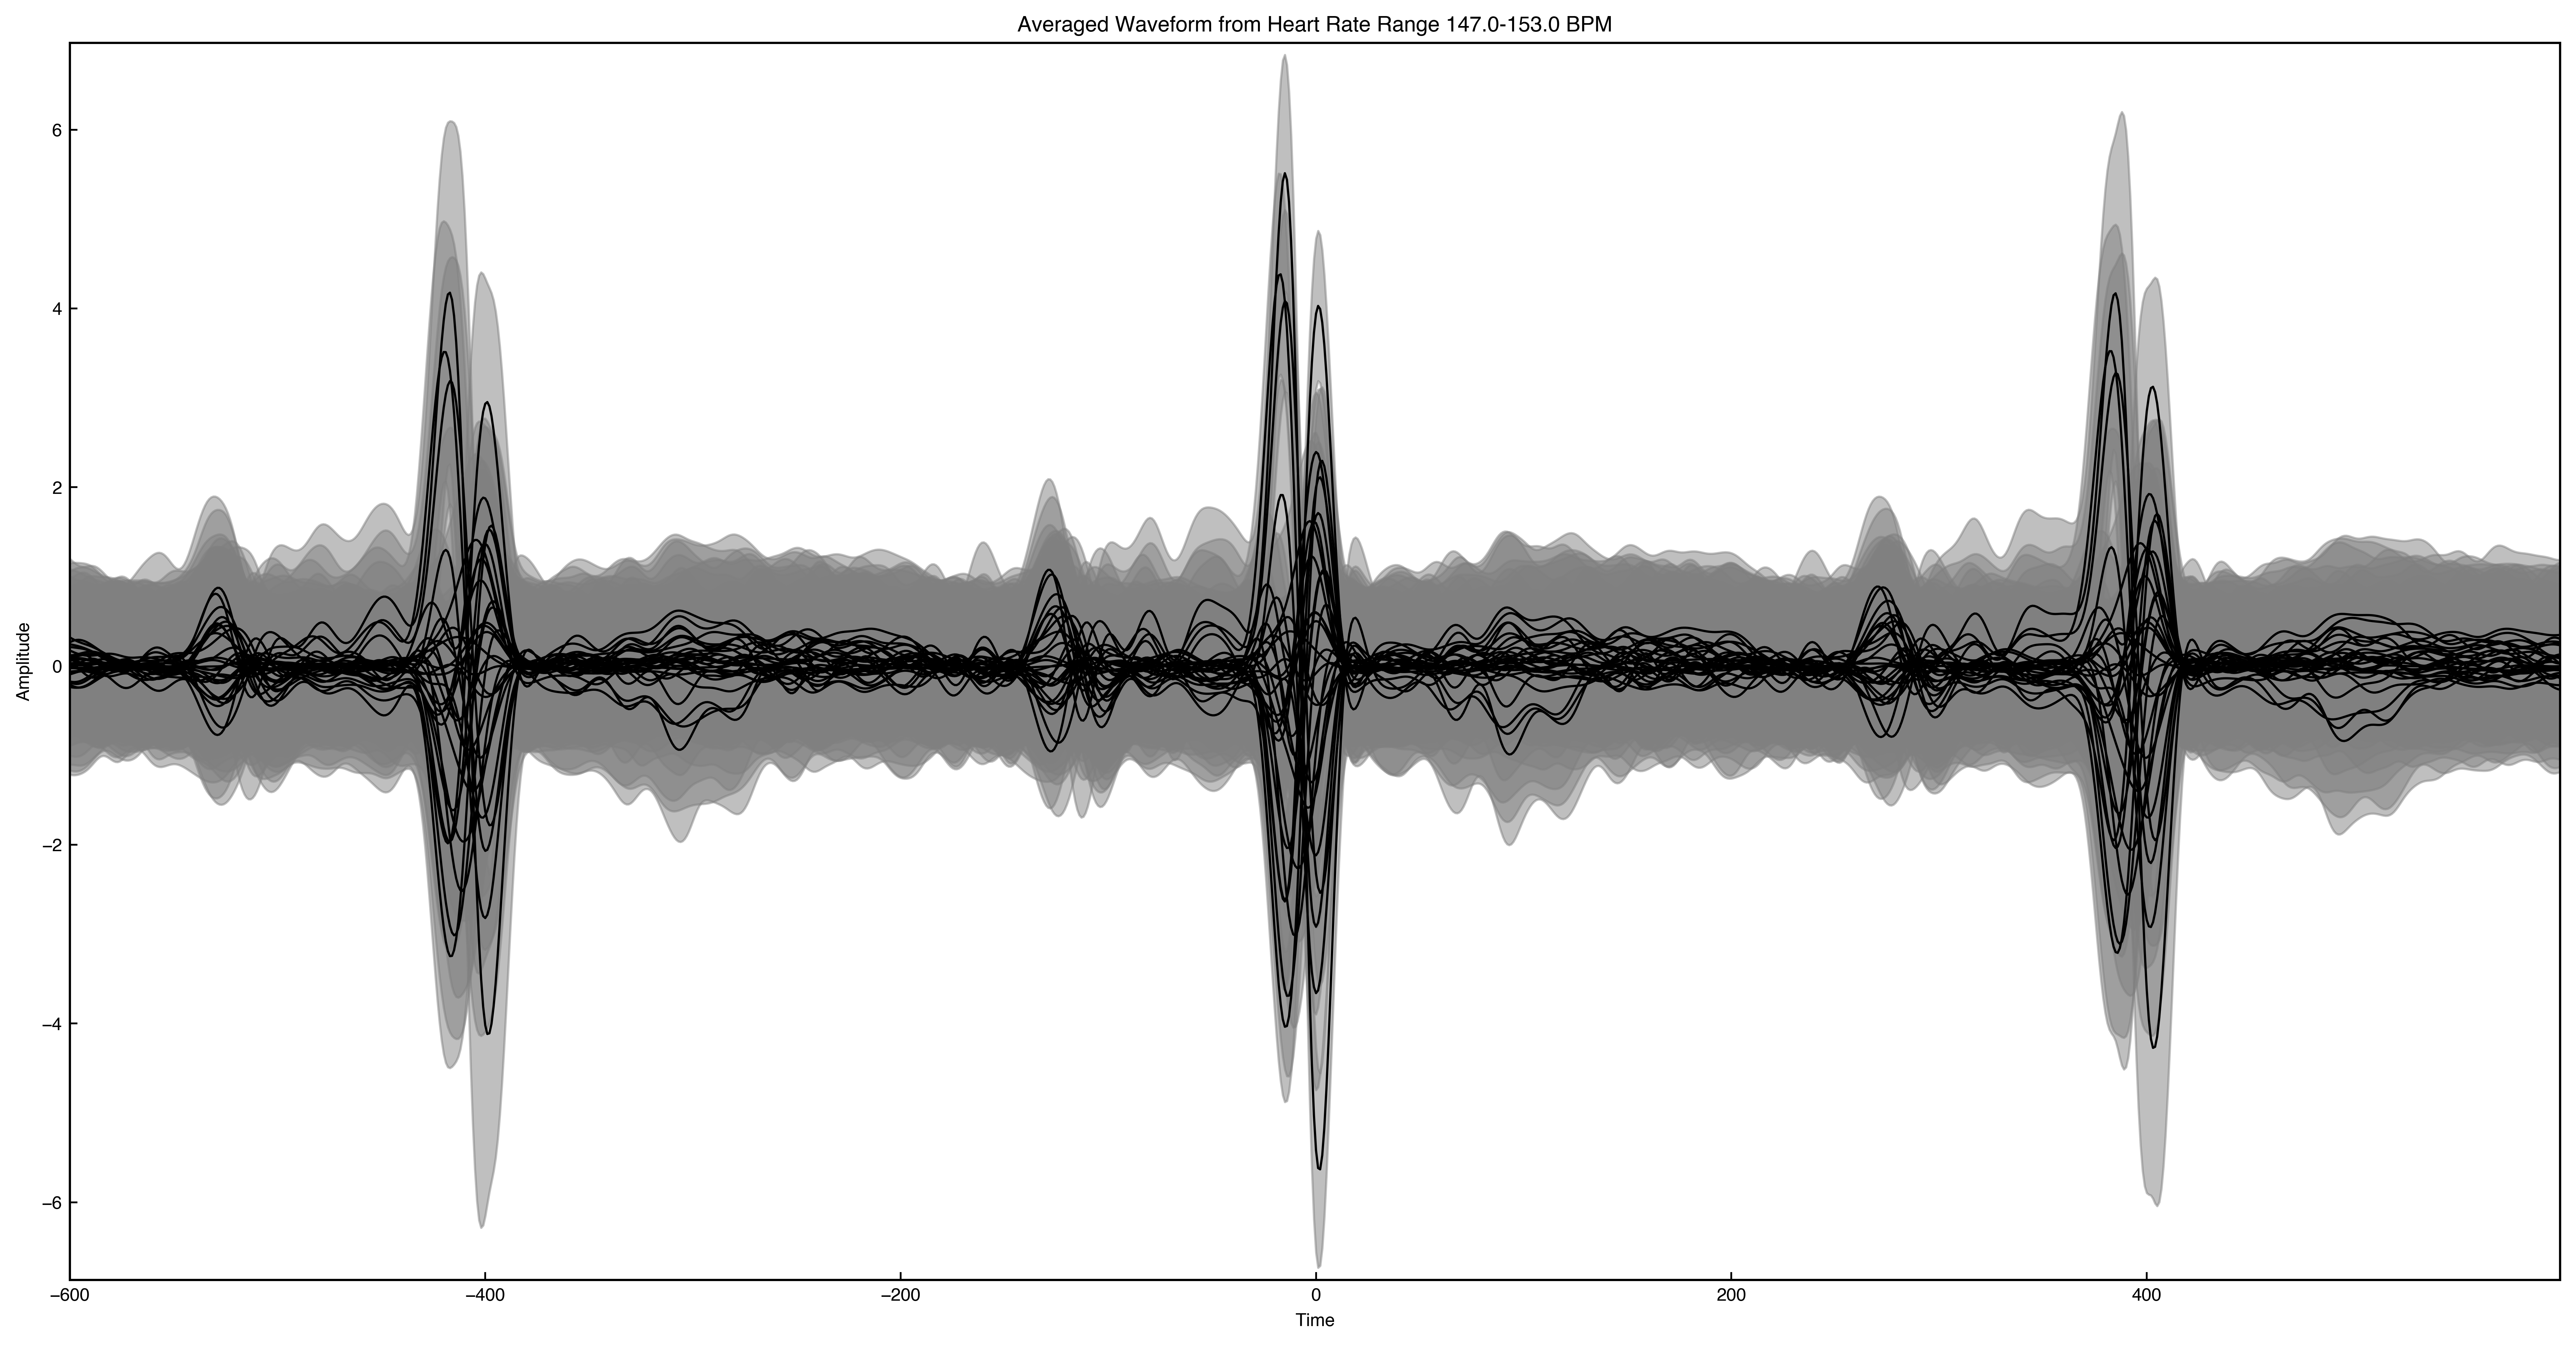

In [15]:
## Selective Heartbeat Averaging

# select hr segments within the given tolerances
range_segments = identify_hr_range_segments(
    heartRate,
    min_hr=np.median(heartRate) - 3,
    max_hr=np.median(heartRate) + 3,
    plot=True,
    min_segment_length=3,
    plt_save=False,
)

# average the segments from the remaining field measurements after maternal cancelation
avg_waveform, std_waveform = avg_channels_hr_range(
    remaining_fetal,
    peaks,
    heartRate,
    window_size=int(60/np.median(heartRate)*fs)*3, # show three heartbeats
    denoise=False,
    plot=True,
    min_hr=np.median(heartRate) - 3,
    max_hr=np.median(heartRate) + 3,
    plt_save=False,
)